In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df['Factory'] = ''

In [2]:
df = pd.read_csv(
    "/content/nassau_candy_cleaned.csv"
)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (10194, 32)
   Row ID                      Order ID Order Date   Ship Date  \
0       1  US-2021-103800-CHO-MIL-31000   3/1/2024  30-06-2026   
1       2  US-2021-112326-CHO-TRI-54000   4/1/2024    1/7/2026   
2       3  US-2021-112326-CHO-NUT-13000   4/1/2024    1/7/2026   
3       4  US-2021-112326-CHO-SCR-58000   4/1/2024    1/7/2026   
4       5  US-2021-141817-CHO-TRI-54000   5/1/2024    5/7/2026   

        Ship Mode  Customer ID Country/Region          City State/Province  \
0  Standard Class       103800  United States       Houston          Texas   
1  Standard Class       112326  United States    Naperville       Illinois   
2  Standard Class       112326  United States    Naperville       Illinois   
3  Standard Class       112326  United States    Naperville       Illinois   
4  Standard Class       141817  United States  Philadelphia   Pennsylvania   

  Postal Code  ... Order Date Parsed Ship Date Parsed Lead Time Days  \
0       77095  ...        2024-01-0

In [15]:
df['Factory'] = ''

In [3]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Calculated Gross Profit', 'Profit Difference', 'Order Date Raw', 'Ship Date Raw', 'Order Date Parsed', 'Ship Date Parsed', 'Lead Time Days', 'Profit Margin', 'Sales per Unit', 'Profit per Unit', 'Order Year', 'Order Month', 'Order Quarter', 'Order DayOfWeek']


In [6]:
required_columns = [
    "Factory",
    "Region",
    "Division",
    "Product Name",
    "Sales",
    "Units",
    "Gross Profit",
    "Cost",
    "Lead Time Days"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("Missing required columns:", missing_columns)

Missing required columns: []


In [9]:
route_data = (
    df.groupby(
        ["Factory", "Region"],
        as_index=False
    )
    .agg(
        Orders=("Order ID", "nunique"),
        Units=("Units", "sum"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Cost=("Cost", "sum"),
        Avg_Lead_Time=("Lead Time Days", "mean"),
        Median_Lead_Time=("Lead Time Days", "median")
    )
)

print(route_data)

  Factory    Region  Orders  Units     Sales  Gross_Profit      Cost  \
0          Atlantic    2476  11159  41197.24      26973.70  14223.54   
1              Gulf    1350   6209  22247.26      14700.67   7546.59   
2          Interior    1979   8820  32037.60      21282.49  10755.11   
3           Pacific    2744  12466  46301.53      30485.94  15815.59   

   Avg_Lead_Time  Median_Lead_Time  
0    1322.745144            1274.0  
1    1311.374691            1274.0  
2    1323.091221            1274.0  
3    1322.194897            1274.0  


In [10]:
route_data["Profit_Margin"] = np.where(
    route_data["Sales"] != 0,
    (route_data["Gross_Profit"] / route_data["Sales"]) * 100,
    0
)

print(route_data.head())

  Factory    Region  Orders  Units     Sales  Gross_Profit      Cost  \
0          Atlantic    2476  11159  41197.24      26973.70  14223.54   
1              Gulf    1350   6209  22247.26      14700.67   7546.59   
2          Interior    1979   8820  32037.60      21282.49  10755.11   
3           Pacific    2744  12466  46301.53      30485.94  15815.59   

   Avg_Lead_Time  Median_Lead_Time  Profit_Margin  
0    1322.745144            1274.0      65.474532  
1    1311.374691            1274.0      66.078564  
2    1323.091221            1274.0      66.429726  
3    1322.194897            1274.0      65.842187  


In [11]:
cluster_features = [
    "Orders",
    "Units",
    "Sales",
    "Gross_Profit",
    "Avg_Lead_Time",
    "Profit_Margin"
]

X = route_data[cluster_features].copy()

print(X.head())

   Orders  Units     Sales  Gross_Profit  Avg_Lead_Time  Profit_Margin
0    2476  11159  41197.24      26973.70    1322.745144      65.474532
1    1350   6209  22247.26      14700.67    1311.374691      66.078564
2    1979   8820  32037.60      21282.49    1323.091221      66.429726
3    2744  12466  46301.53      30485.94    1322.194897      65.842187


In [12]:
X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median())

print("Missing values:")
print(X.isnull().sum())

Missing values:
Orders           0
Units            0
Sales            0
Gross_Profit     0
Avg_Lead_Time    0
Profit_Margin    0
dtype: int64


In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (4, 6)


In [16]:
silhouette_scores = {}

# Adjust the range for k to be between 2 and n_samples - 1 (exclusive of n_samples)
# X_scaled.shape[0] gives the number of samples
for k in range(2, X_scaled.shape[0]):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores[k] = score

print(silhouette_scores)

{2: np.float64(0.4181907637501824), 3: np.float64(0.2761933696574586)}


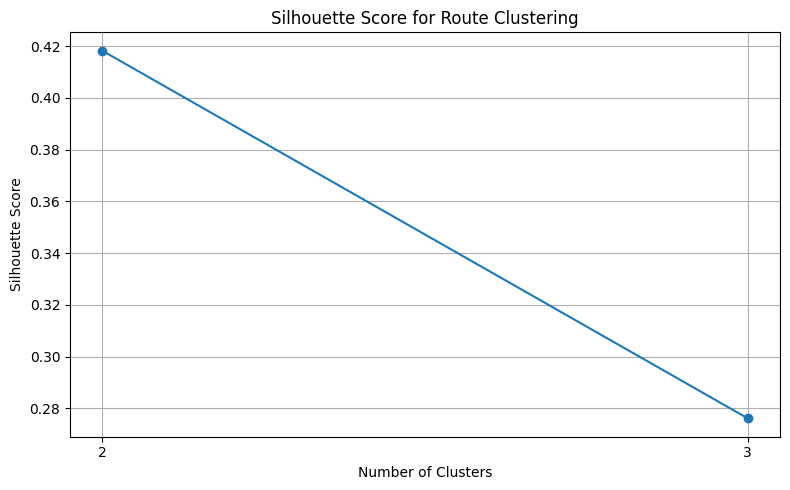

In [21]:
import os

plt.figure(figsize=(8, 5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Route Clustering")
# Adjust xticks to only show the keys present in silhouette_scores
plt.xticks(list(silhouette_scores.keys()))
plt.grid(True)

plt.tight_layout()

# Define the directory path
output_dir = "./05_Results"
# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, "Clustering_Silhouette_Score.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
best_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

print("Best number of clusters:", best_k)
print(
    "Best silhouette score:",
    silhouette_scores[best_k]
)

Best number of clusters: 2
Best silhouette score: 0.4181907637501824


In [23]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

route_data["Cluster"] = kmeans.fit_predict(X_scaled)

print(route_data)

  Factory    Region  Orders  Units     Sales  Gross_Profit      Cost  \
0          Atlantic    2476  11159  41197.24      26973.70  14223.54   
1              Gulf    1350   6209  22247.26      14700.67   7546.59   
2          Interior    1979   8820  32037.60      21282.49  10755.11   
3           Pacific    2744  12466  46301.53      30485.94  15815.59   

   Avg_Lead_Time  Median_Lead_Time  Profit_Margin  Cluster  
0    1322.745144            1274.0      65.474532        1  
1    1311.374691            1274.0      66.078564        0  
2    1323.091221            1274.0      66.429726        0  
3    1322.194897            1274.0      65.842187        1  


In [24]:
cluster_summary = (
    route_data
    .groupby("Cluster", as_index=False)
    .agg(
        Routes=("Region", "count"),
        Avg_Lead_Time=("Avg_Lead_Time", "mean"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Gross_Profit", "sum"),
        Avg_Profit_Margin=("Profit_Margin", "mean")
    )
)

print(cluster_summary)

   Cluster  Routes  Avg_Lead_Time  Total_Sales  Total_Profit  \
0        0       2    1317.232956     54284.86      35983.16   
1        1       2    1322.470021     87498.77      57459.64   

   Avg_Profit_Margin  
0          66.254145  
1          65.658359  


In [26]:
import os

# Ensure the output directory exists, using the same logic as the plot saving cell
output_dir = "./05_Results"
os.makedirs(output_dir, exist_ok=True)

route_data.to_csv(
    os.path.join(output_dir, "route_clusters.csv"),
    index=False
)

cluster_summary.to_csv(
    os.path.join(output_dir, "cluster_summary.csv"),
    index=False
)

print("Clustering files saved successfully.")

Clustering files saved successfully.


In [27]:
slow_routes = (
    route_data
    .sort_values(
        "Avg_Lead_Time",
        ascending=False
    )
)

print(
    slow_routes[
        [
            "Factory",
            "Region",
            "Avg_Lead_Time",
            "Sales",
            "Gross_Profit",
            "Cluster"
        ]
    ].head(10)
)

  Factory    Region  Avg_Lead_Time     Sales  Gross_Profit  Cluster
2          Interior    1323.091221  32037.60      21282.49        0
0          Atlantic    1322.745144  41197.24      26973.70        1
3           Pacific    1322.194897  46301.53      30485.94        1
1              Gulf    1311.374691  22247.26      14700.67        0


In [31]:
import os

slow_routes.to_csv(
    os.path.join(output_dir, "slow_routes.csv"),
    index=False
)

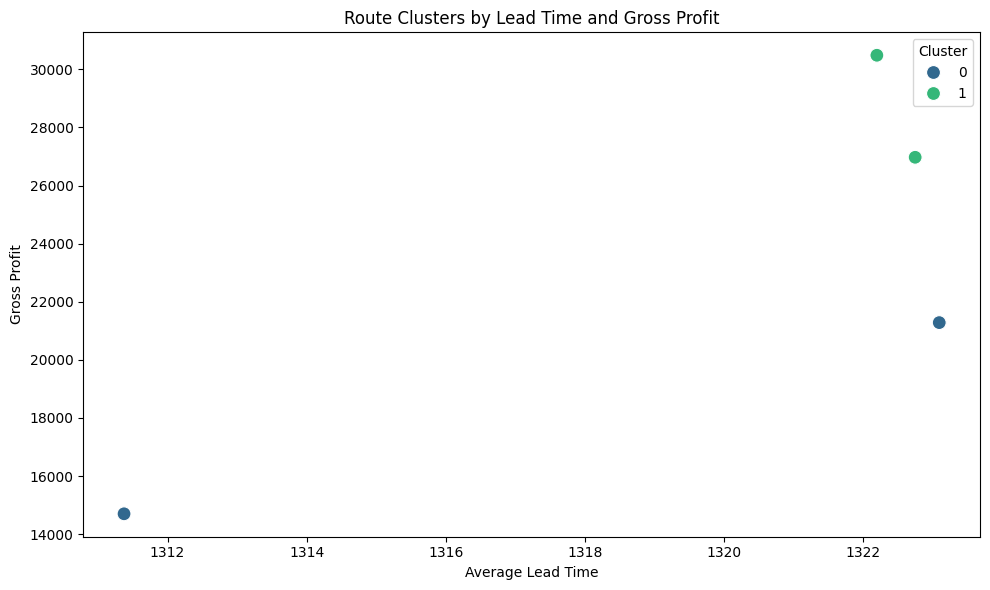

In [33]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=route_data,
    x="Avg_Lead_Time",
    y="Gross_Profit",
    hue="Cluster",
    palette="viridis",
    s=100
)

plt.title("Route Clusters by Lead Time and Gross Profit")
plt.xlabel("Average Lead Time")
plt.ylabel("Gross Profit")

plt.tight_layout()

import os

plt.savefig(
    os.path.join(output_dir, "Route_Clusters.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()